In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

The following will be plots for the exam presentation

In [2]:
# No-regrowth experiment_data.csv for scenario 1 (random)
scenario_random_noregrowth = pd.read_csv("../checkpoints/random/0610_1429/experiment_data.csv")

# No-regrowth experiment_data.csv for scenario 3 (two-island)
scenario_two_island_noregrowth = pd.read_csv("../checkpoints/two-island/0610_1429/experiment_data.csv")

# Regrowth scenario 1 (random)
scenario_random_regrowth = pd.read_csv("../checkpoints/random/0611_1318/experiment_data.csv")

# Regrowth scenario 3 (two-island)
scenario_two_island_regrowth = pd.read_csv("../checkpoints/two-island/0611_1317/experiment_data.csv")


In [3]:
# Apply smoothing to make trends visible
window = 20
df1_s = scenario_random_noregrowth.rolling(window=window, min_periods=1).mean()
df2_s = scenario_two_island_noregrowth.rolling(window=window, min_periods=1).mean()
df3_s = scenario_random_regrowth.rolling(window=window, min_periods=1).mean()
df4_s = scenario_two_island_regrowth.rolling(window=window, min_periods=1).mean()

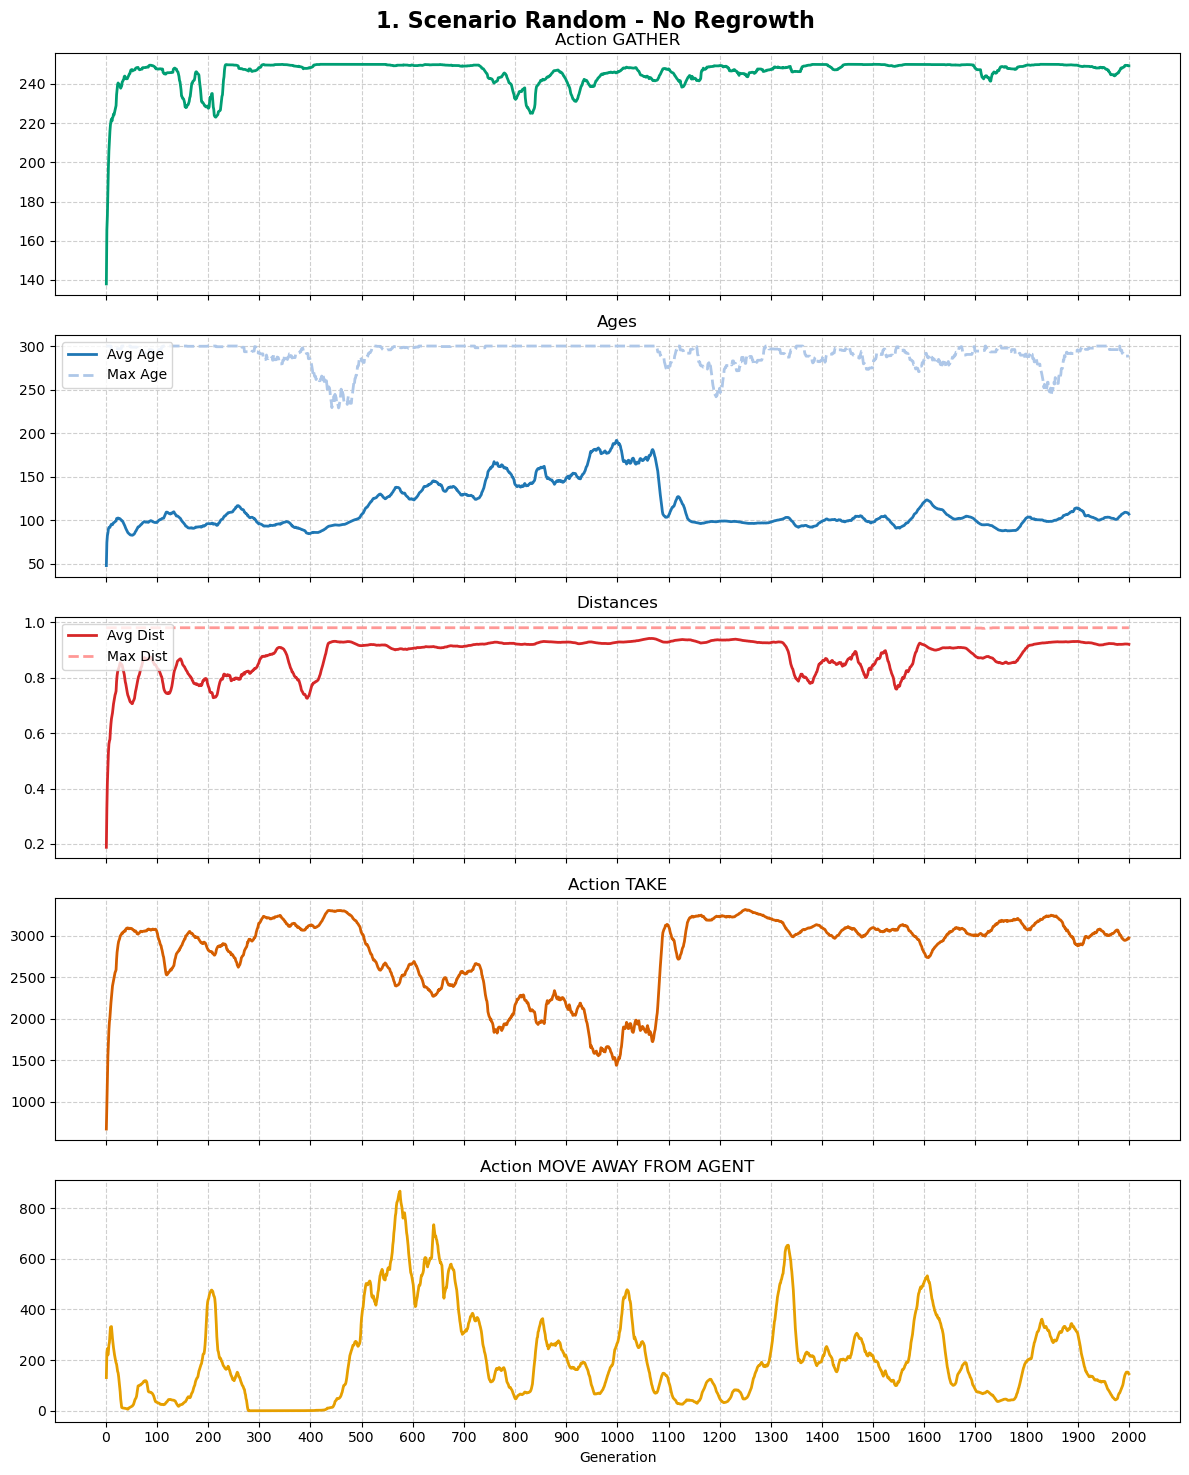

In [12]:
# Plot 1: Scenario Random - No Regrowth
# ---------------------------------------------------------
fig1, axes1 = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
fig1.suptitle("1. Scenario Random - No Regrowth", fontsize=16, fontweight='bold', y=0.98)

axes1[0].plot(scenario_random_noregrowth['Generation'], df1_s['Action_GATHER'], color="#009E73", linewidth=2)
axes1[0].set_title("Action GATHER")

axes1[1].plot(scenario_random_noregrowth['Generation'], df1_s['Avg_Age'], label="Avg Age", linewidth=2, color="#1f77b4")
axes1[1].plot(scenario_random_noregrowth['Generation'], df1_s['Max_Age'], label="Max Age", linewidth=2, color="#aec7e8", linestyle='--')
axes1[1].set_title("Ages")
axes1[1].legend(loc="upper left")

axes1[2].plot(scenario_random_noregrowth['Generation'], df1_s['Avg_Dist'], label="Avg Dist", linewidth=2, color="#d62728")
axes1[2].plot(scenario_random_noregrowth['Generation'], df1_s['Max_Dist'], label="Max Dist", linewidth=2, color="#ff9896", linestyle='--')
axes1[2].set_title("Distances")
axes1[2].legend(loc="upper left")

axes1[3].plot(scenario_random_noregrowth['Generation'], df1_s['Action_TAKE'], color="#D55E00", linewidth=2)
axes1[3].set_title("Action TAKE")

axes1[4].plot(scenario_random_noregrowth['Generation'], df1_s['Action_MOVE_AWAY_FROM_AGENT'], color="#E69F00", linewidth=2)
axes1[4].set_title("Action MOVE AWAY FROM AGENT")
axes1[4].set_xlabel("Generation")
axes1[4].set_xticks(np.arange(0, scenario_random_noregrowth['Generation'].max() + 1, 100))

for ax in axes1:
    ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

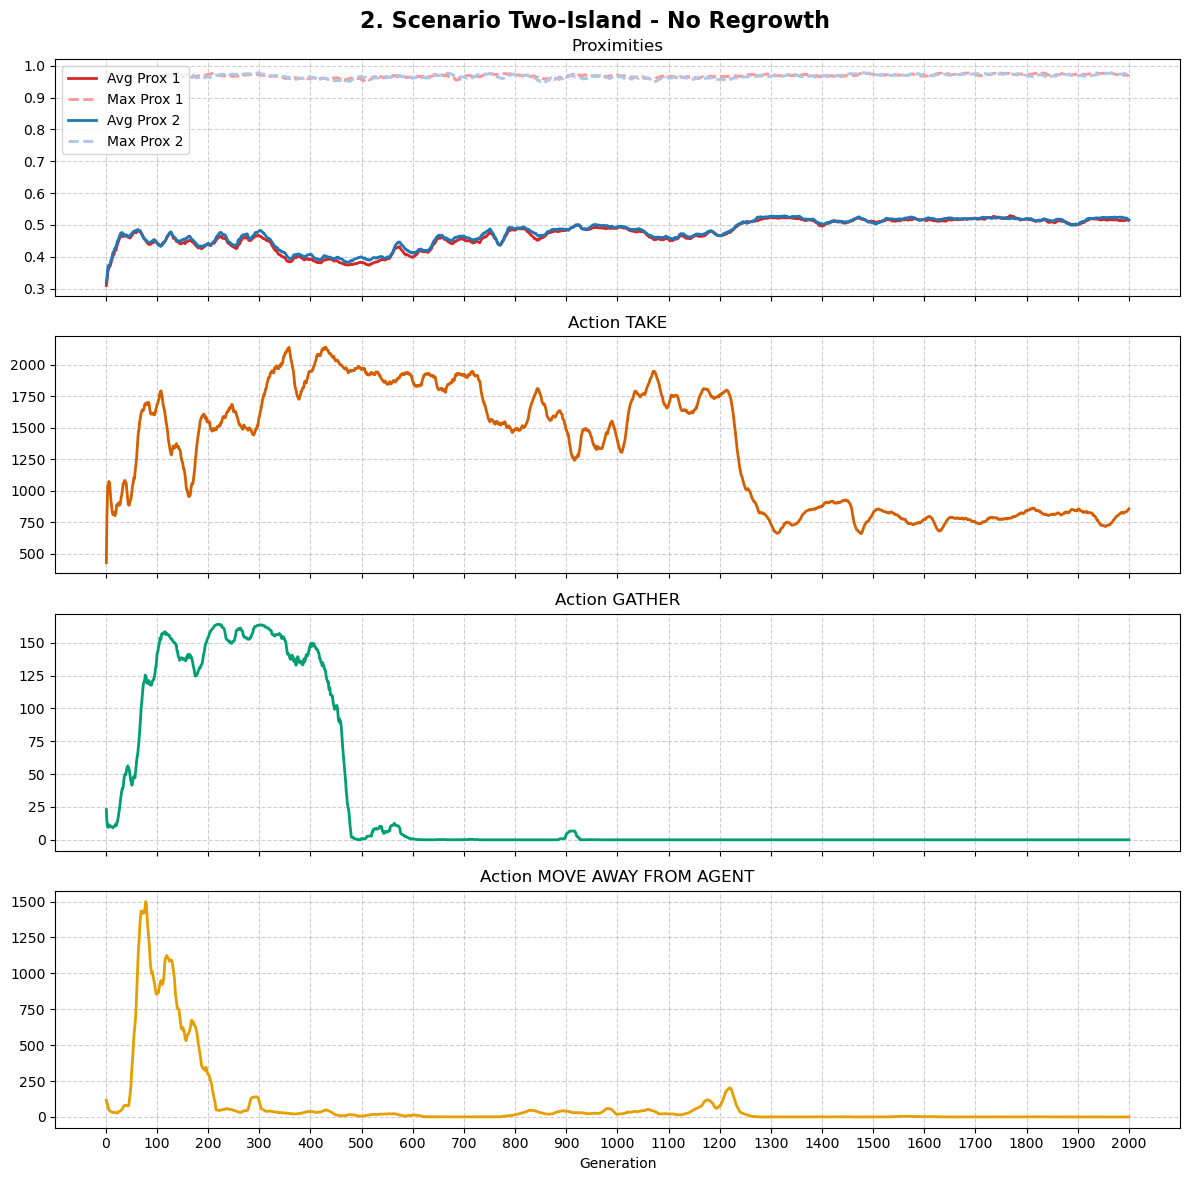

In [17]:
# Plot 2: Scenario Two-Island - No Regrowth
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
fig2.suptitle("2. Scenario Two-Island - No Regrowth", fontsize=16, fontweight='bold', y=0.98)

axes2[0].plot(scenario_two_island_noregrowth['Generation'], df2_s['Avg_Prox_1'], label="Avg Prox 1", linewidth=2, color="#d62728")
axes2[0].plot(scenario_two_island_noregrowth['Generation'], df2_s['Max_Prox_1'], label="Max Prox 1", linewidth=2, color="#ff9896", linestyle='--')
axes2[0].plot(scenario_two_island_noregrowth['Generation'], df2_s['Avg_Prox_2'], label="Avg Prox 2", linewidth=2, color="#1f77b4")
axes2[0].plot(scenario_two_island_noregrowth['Generation'], df2_s['Max_Prox_2'], label="Max Prox 2", linewidth=2, color="#aec7e8", linestyle='--')
axes2[0].set_title("Proximities")
axes2[0].legend(loc="upper left")

axes2[1].plot(scenario_two_island_noregrowth['Generation'], df2_s['Action_TAKE'], color="#D55E00", linewidth=2)
axes2[1].set_title("Action TAKE")

axes2[2].plot(scenario_two_island_noregrowth['Generation'], df2_s['Action_GATHER'], color="#009E73", linewidth=2)
axes2[2].set_title("Action GATHER")

axes2[3].plot(scenario_two_island_noregrowth['Generation'], df2_s['Action_MOVE_AWAY_FROM_AGENT'], color="#E69F00", linewidth=2)
axes2[3].set_title("Action MOVE AWAY FROM AGENT")
axes2[3].set_xlabel("Generation")
axes2[3].set_xticks(np.arange(0, scenario_two_island_noregrowth['Generation'].max() + 1, 100))


for ax in axes2:
    ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

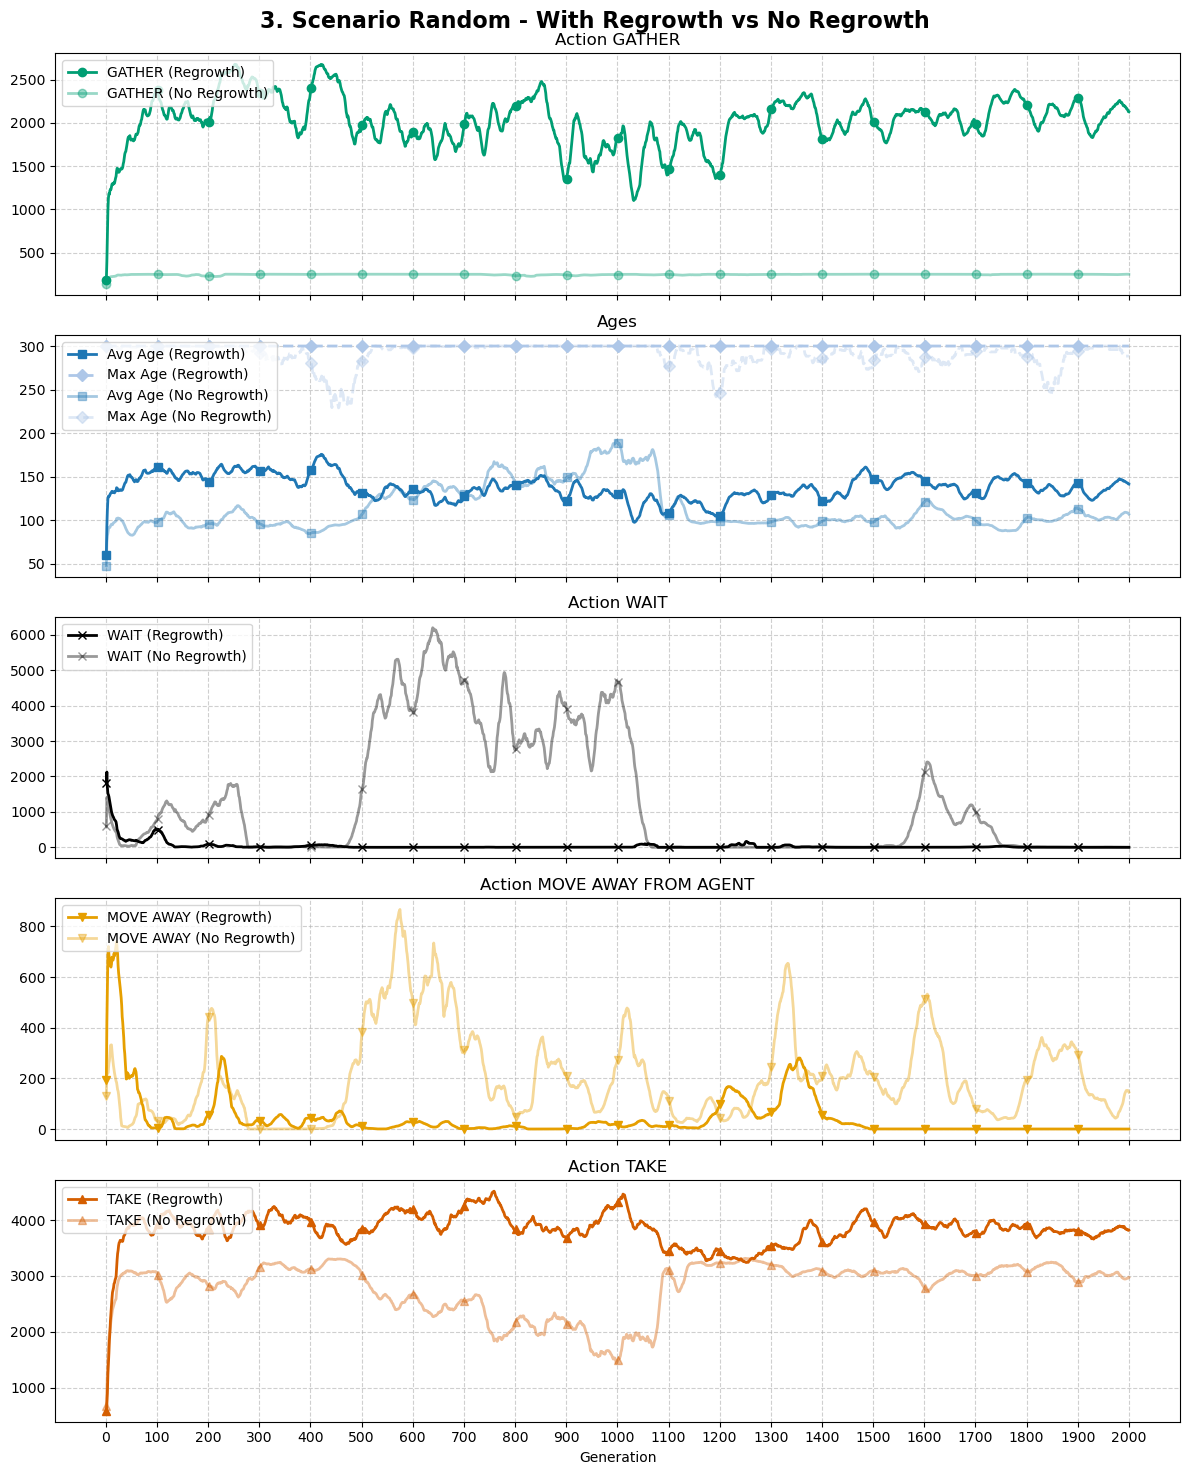

In [18]:
# Plot 3: Scenario Random - With Regrowth vs No Regrowth
# ---------------------------------------------------------
fig3, axes3 = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
fig3.suptitle("3. Scenario Random - With Regrowth vs No Regrowth", fontsize=16, fontweight='bold', y=0.98)

spacing = 100

axes3[0].plot(scenario_random_regrowth['Generation'], df3_s['Action_GATHER'], label="GATHER (Regrowth)", color="#009E73", linewidth=2, marker='o', markevery=spacing)
axes3[0].plot(scenario_random_noregrowth['Generation'], df1_s['Action_GATHER'], label="GATHER (No Regrowth)", color="#009E73", linewidth=2, alpha=0.4, marker='o', markevery=spacing)
axes3[0].set_title("Action GATHER")
axes3[0].legend(loc="upper left")

axes3[1].plot(scenario_random_regrowth['Generation'], df3_s['Avg_Age'], label="Avg Age (Regrowth)", linewidth=2, color="#1f77b4", marker='s', markevery=spacing)
axes3[1].plot(scenario_random_regrowth['Generation'], df3_s['Max_Age'], label="Max Age (Regrowth)", linewidth=2, color="#aec7e8", linestyle='--', marker='D', markevery=spacing)
axes3[1].plot(scenario_random_noregrowth['Generation'], df1_s['Avg_Age'], label="Avg Age (No Regrowth)", linewidth=2, color="#1f77b4", alpha=0.4, marker='s', markevery=spacing)
axes3[1].plot(scenario_random_noregrowth['Generation'], df1_s['Max_Age'], label="Max Age (No Regrowth)", linewidth=2, color="#aec7e8", linestyle='--', alpha=0.4, marker='D', markevery=spacing)
axes3[1].set_title("Ages")
axes3[1].legend(loc="upper left")

axes3[2].plot(scenario_random_regrowth['Generation'], df3_s['Action_WAIT'], label="WAIT (Regrowth)", color="#000000", linewidth=2, marker='x', markevery=spacing)
axes3[2].plot(scenario_random_noregrowth['Generation'], df1_s['Action_WAIT'], label="WAIT (No Regrowth)", color="#000000", linewidth=2, alpha=0.4, marker='x', markevery=spacing)
axes3[2].set_title("Action WAIT")
axes3[2].legend(loc="upper left")

axes3[3].plot(scenario_random_regrowth['Generation'], df3_s['Action_MOVE_AWAY_FROM_AGENT'], label="MOVE AWAY (Regrowth)", color="#E69F00", linewidth=2, marker='v', markevery=spacing)
axes3[3].plot(scenario_random_noregrowth['Generation'], df1_s['Action_MOVE_AWAY_FROM_AGENT'], label="MOVE AWAY (No Regrowth)", color="#E69F00", linewidth=2, alpha=0.4, marker='v', markevery=spacing)
axes3[3].set_title("Action MOVE AWAY FROM AGENT")
axes3[3].legend(loc="upper left")

axes3[4].plot(scenario_random_regrowth['Generation'], df3_s['Action_TAKE'], label="TAKE (Regrowth)", color="#D55E00", linewidth=2, marker='^', markevery=spacing)
axes3[4].plot(scenario_random_noregrowth['Generation'], df1_s['Action_TAKE'], label="TAKE (No Regrowth)", color="#D55E00", linewidth=2, alpha=0.4, marker='^', markevery=spacing)
axes3[4].set_title("Action TAKE")
axes3[4].legend(loc="upper left")
axes3[4].set_xlabel("Generation")
axes3[4].set_xticks(np.arange(0, scenario_two_island_noregrowth['Generation'].max() + 1, 100))

for ax in axes3:
    ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


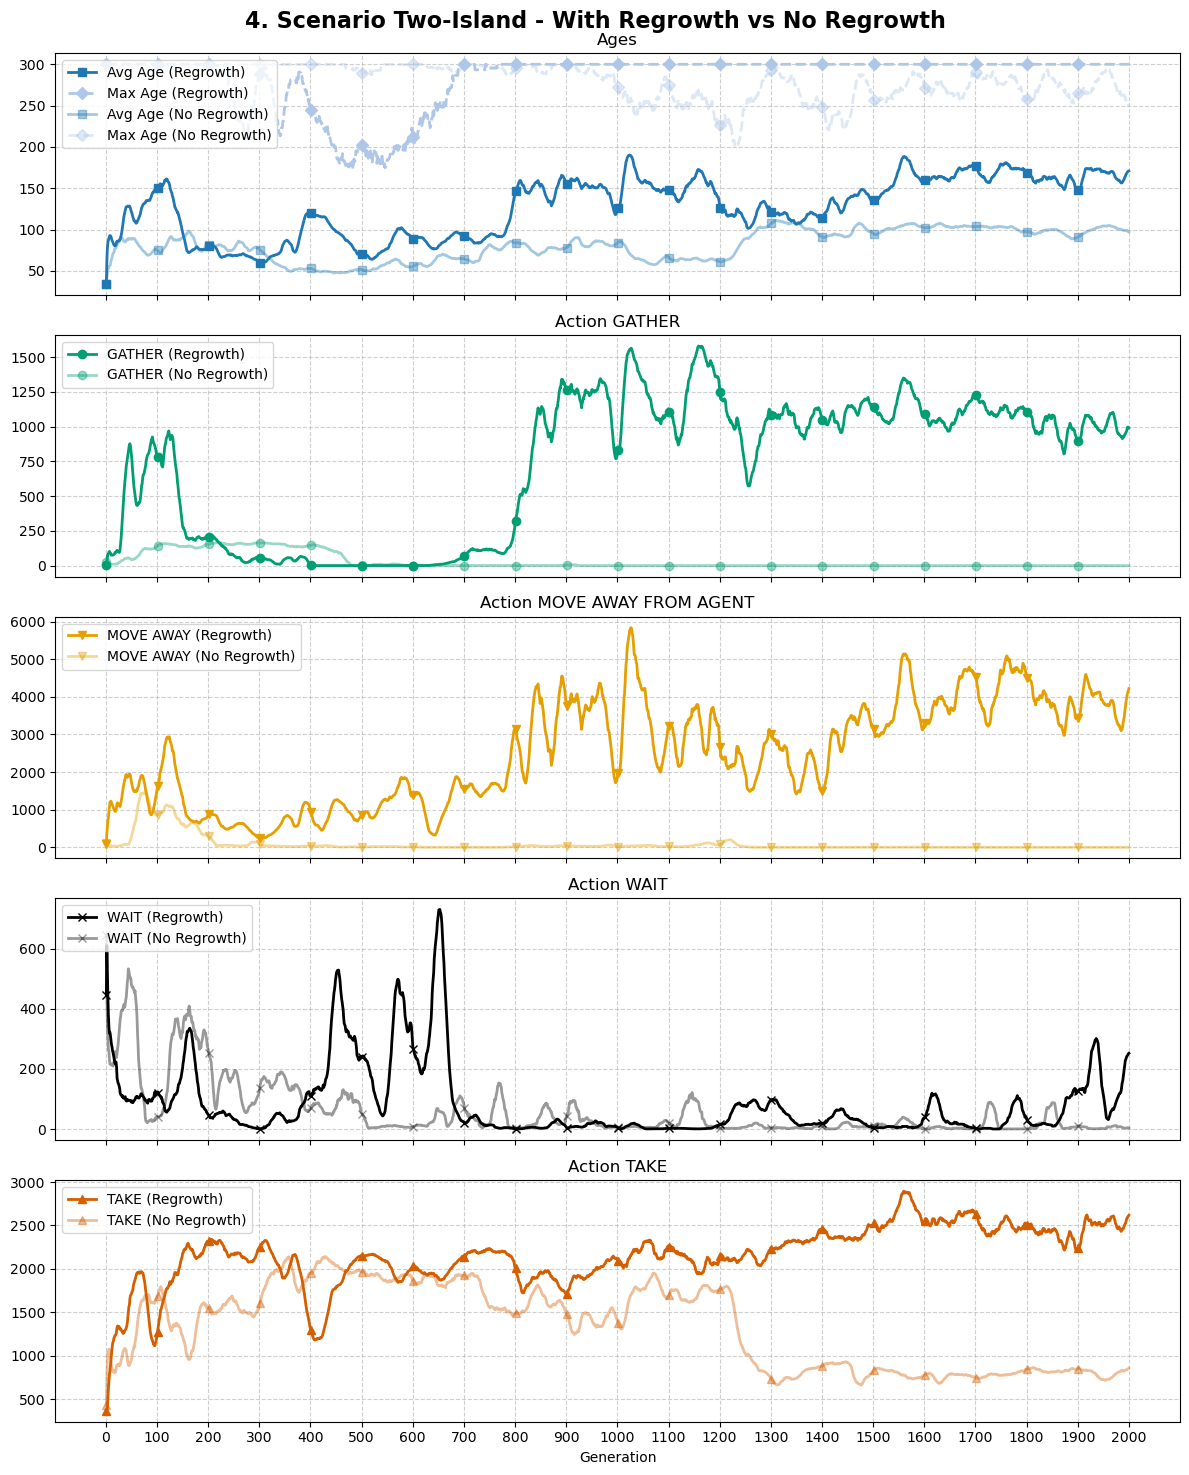

In [19]:
# Plot 4: Scenario Two-Island - With Regrowth vs No Regrowth
# ---------------------------------------------------------
fig4, axes4 = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
fig4.suptitle("4. Scenario Two-Island - With Regrowth vs No Regrowth", fontsize=16, fontweight='bold', y=0.98)

# Set marker spacing to avoid clutter (adjust this depending on total generations, e.g. 50 or 100)
spacing = 100

axes4[0].plot(scenario_two_island_regrowth['Generation'], df4_s['Avg_Age'], label="Avg Age (Regrowth)", color="#1f77b4", linewidth=2, marker='s', markevery=spacing)
axes4[0].plot(scenario_two_island_regrowth['Generation'], df4_s['Max_Age'], label="Max Age (Regrowth)", color="#aec7e8", linewidth=2, linestyle='--', marker='D', markevery=spacing)
axes4[0].plot(scenario_two_island_noregrowth['Generation'], df2_s['Avg_Age'], label="Avg Age (No Regrowth)", color="#1f77b4", linewidth=2, alpha=0.4, marker='s', markevery=spacing)
axes4[0].plot(scenario_two_island_noregrowth['Generation'], df2_s['Max_Age'], label="Max Age (No Regrowth)", color="#aec7e8", linewidth=2, alpha=0.4, linestyle='--', marker='D', markevery=spacing)
axes4[0].set_title("Ages")
axes4[0].legend(loc="upper left")

axes4[1].plot(scenario_two_island_regrowth['Generation'], df4_s['Action_GATHER'], label="GATHER (Regrowth)", color="#009E73", linewidth=2, marker='o', markevery=spacing)
axes4[1].plot(scenario_two_island_noregrowth['Generation'], df2_s['Action_GATHER'], label="GATHER (No Regrowth)", color="#009E73", linewidth=2, alpha=0.4, marker='o', markevery=spacing)
axes4[1].set_title("Action GATHER")
axes4[1].legend(loc="upper left")

axes4[2].plot(scenario_two_island_regrowth['Generation'], df4_s['Action_MOVE_AWAY_FROM_AGENT'], label="MOVE AWAY (Regrowth)", color="#E69F00", linewidth=2, marker='v', markevery=spacing)
axes4[2].plot(scenario_two_island_noregrowth['Generation'], df2_s['Action_MOVE_AWAY_FROM_AGENT'], label="MOVE AWAY (No Regrowth)", color="#E69F00", linewidth=2, alpha=0.4, marker='v', markevery=spacing)
axes4[2].set_title("Action MOVE AWAY FROM AGENT")
axes4[2].legend(loc="upper left")

axes4[3].plot(scenario_two_island_regrowth['Generation'], df4_s['Action_WAIT'], label="WAIT (Regrowth)", color="#000000", linewidth=2, marker='x', markevery=spacing)
axes4[3].plot(scenario_two_island_noregrowth['Generation'], df2_s['Action_WAIT'], label="WAIT (No Regrowth)", color="#000000", linewidth=2, alpha=0.4, marker='x', markevery=spacing)
axes4[3].set_title("Action WAIT")
axes4[3].legend(loc="upper left")

axes4[4].plot(scenario_two_island_regrowth['Generation'], df4_s['Action_TAKE'], label="TAKE (Regrowth)", color="#D55E00", linewidth=2, marker='^', markevery=spacing)
axes4[4].plot(scenario_two_island_noregrowth['Generation'], df2_s['Action_TAKE'], label="TAKE (No Regrowth)", color="#D55E00", linewidth=2, alpha=0.4, marker='^', markevery=spacing)
axes4[4].set_title("Action TAKE")
axes4[4].legend(loc="upper left")
axes4[4].set_xlabel("Generation")
axes4[4].set_xticks(np.arange(0, scenario_two_island_noregrowth['Generation'].max() + 1, 100))

for ax in axes4:
    ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
